# Final Strategy: Sizing the Parent Long by Child Inclusion Probability

This notebook is the trimmed, decision-ready version of
`inclusion_prob_sizing_classification.ipynb`. That notebook also tried a
decision-tree **classification** of the parent's 252d return into three
buckets. That section has been removed from here — a review found it had two
real problems, not just a small-n caveat:

1. **Hyperparameter leakage.** The tree's pruning level (`ccp_alpha`) was
   chosen by maximizing the same LOO-CV accuracy that was then reported as
   the result — i.e. the test metric was used to pick the model. The
   reported 50% vs. the 38% majority-class baseline came down to exactly one
   flipped prediction out of 16, which is not distinguishable from noise at
   that alpha-search granularity.
2. **A structural blind spot.** The winning tree had only 2 leaves for a
   3-class problem, which means it could **never** predict the
   "underperform" bucket — not a bad draw, a guarantee of the topology. The
   one thing you'd actually want a downside classifier for, it structurally
   couldn't do.

What survives — and is the whole content of this notebook — is the
**position-sizing result**: weighting each parent long by its child's
`prob_included` instead of holding every name equal-weight. At the end,
Section 4 revisits the tree idea with both bugs fixed (nested LOO for alpha
selection, and a floor of 3 leaves so the model can represent all three
outcomes), used as a small, honest overlay on top of the sizing rule rather
than as a replacement for it.

**n = 16 throughout.** Every number below is computed on 16 spinoff events
with a full 252-trading-day parent price path and a usable `prob_included`.
Treat this as a well-argued hypothesis, not a strategy sized with real
capital.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)

RAW_DIR   = Path('../data/raw')
CLEAN_DIR = Path('../data/clean')

## 1. Load `prob_included` and rebuild the parent's post-completion CAR

Identical construction to the source notebook: `prob_included` loaded from
the LOO-CV model's saved output, parent CAR path built with β estimated on
the trailing 252 trading days before announcement (clipped to [0.3, 2.5]),
`hedged_car = cumsum(ret - β·sprtrn)` from the effective date.

In [2]:
prob_df = pd.read_csv(CLEAN_DIR / 'inclusion_probability_results.csv', parse_dates=['effective_date'])
prob_df['prob_included'] = prob_df['P(included) %'] / 100
print(f'Loaded prob_included for {len(prob_df)} events.')

events = pd.read_csv(CLEAN_DIR / 'spinoff_events_merged.csv', parse_dates=['announce_date', 'effective_date'])
events = events.drop_duplicates(
    subset=['parent_ticker', 'permno', 'announce_date', 'effective_date', 'spinoff_ticker']
).reset_index(drop=True)
events = events[(events['effective_date'] - events['announce_date']).dt.days >= 0].reset_index(drop=True)

crsp    = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet').sort_values(['permno', 'date']).reset_index(drop=True)
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')
by_permno = {p: g.reset_index(drop=True) for p, g in crsp.groupby('permno')}

def estimate_beta(permno, before_date, window=252, min_obs=60):
    g = by_permno.get(permno)
    if g is None:
        return 1.0
    pos = g.index[g['date'] < before_date]
    if len(pos) < min_obs:
        return 1.0
    i0 = pos[-1]
    w = g.iloc[max(0, i0 - window):i0 + 1].merge(idx_ret[['date', 'sprtrn']], on='date', how='left').dropna(subset=['ret', 'sprtrn'])
    if len(w) < min_obs:
        return 1.0
    beta = np.cov(w['ret'], w['sprtrn'])[0, 1] / np.var(w['sprtrn'])
    return float(np.clip(beta, 0.3, 2.5))

events['beta'] = [estimate_beta(p, d) for p, d in zip(events['permno'], events['announce_date'])]

HOLD = 252
paths = []
for _, ev in events.iterrows():
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    pos = g.index[g['date'] <= ev['effective_date']]
    if len(pos) == 0:
        continue
    i0 = pos[-1]
    w = g.iloc[i0:min(len(g), i0 + HOLD + 1)].merge(idx_ret[['date', 'sprtrn']], on='date', how='left')
    if len(w) < HOLD + 1:
        continue
    w['t'] = np.arange(len(w))
    w['hedged_car'] = (w['ret'] - ev['beta'] * w['sprtrn']).cumsum()
    w['parent_ticker'], w['spinoff_ticker'] = ev['parent_ticker'], ev['spinoff_ticker']
    paths.append(w)

all_paths = pd.concat(paths, ignore_index=True)
print(f'Parents with a full {HOLD}-day post-completion path: {all_paths["spinoff_ticker"].nunique()}')

Loaded prob_included for 21 events.


Parents with a full 252-day post-completion path: 20


## 2. The correlation (recap)

`prob_included` vs. parent CAR at four horizons, both naive and
beta-hedged. Only the 252d row is significant — and it's worth noting this
is 1 of 8 horizon x hedging combinations tested, so a Bonferroni-adjusted
threshold at α=0.05 would need p < 0.00625. The 252d/hedged p-value (0.004)
clears that, but not by a wide margin.

In [3]:
car_horizons = [21, 63, 126, 252]
parent_car = (
    all_paths[all_paths['t'].isin(car_horizons)]
    [['parent_ticker', 'spinoff_ticker', 't', 'hedged_car']]
)
parent_car_wide = parent_car.pivot(index=['parent_ticker', 'spinoff_ticker'], columns='t', values='hedged_car')
parent_car_wide.columns = [f'hedged_car_{h}d' for h in parent_car_wide.columns]
parent_car_wide = parent_car_wide.reset_index()

joined = prob_df[['child', 'parent', 'prob_included', 'forced_flow_adv', 'log_child_mktcap']].merge(
    parent_car_wide, left_on=['child', 'parent'], right_on=['spinoff_ticker', 'parent_ticker'], how='inner'
).drop(columns=['spinoff_ticker', 'parent_ticker'])
joined = joined.merge(
    events[['parent_ticker', 'spinoff_ticker', 'beta']].rename(
        columns={'parent_ticker': 'parent', 'spinoff_ticker': 'child'}),
    on=['child', 'parent'], how='left'
)
print(f'Events with prob_included + full {HOLD}d parent path: {len(joined)}')

corr_rows = []
n_tests = 0
for h in car_horizons:
    col = f'hedged_car_{h}d'
    sub = joined.dropna(subset=['prob_included', col])
    r, p = stats.pearsonr(sub['prob_included'], sub[col]) if len(sub) > 2 else (np.nan, np.nan)
    n_tests += 1
    corr_rows.append({'horizon (trading days)': h, 'n': len(sub), 'pearson r': round(r, 3), 'p-value': round(p, 4)})

corr_table = pd.DataFrame(corr_rows)
bonferroni_alpha = 0.05 / (n_tests * 2)  # *2 to mirror the naive+hedged sweep in the source notebook
print('=== Correlation: prob_included vs. parent post-completion CAR (beta-hedged) ===')
display(corr_table)
print(f'Bonferroni-adjusted threshold for {n_tests * 2} combinations tested (this notebook + the naive-CAR version): {bonferroni_alpha:.5f}')

Events with prob_included + full 252d parent path: 16
=== Correlation: prob_included vs. parent post-completion CAR (beta-hedged) ===


,horizon (trading days),n,pearson r,p-value
0,21,16,0.1000,0.7125
1,63,16,0.0350,0.8990
2,126,16,0.3080,0.2459
3,252,16,0.6740,0.0042


Bonferroni-adjusted threshold for 8 combinations tested (this notebook + the naive-CAR version): 0.00625


## 3. The final strategy — position sizing by `prob_included`

**Idea:** instead of an equal-weight book, size each parent long by its
child's `prob_included`, since the 252d correlation says higher
`prob_included` goes with better parent CAR.

$$w_i = \frac{\text{prob\_included}_i}{\overline{\text{prob\_included}}}$$

Dividing by the sample mean keeps average weight at 1.0x — same total gross
exposure as equal-weight, just reallocated across names. No caps, no
shorting the low-probability names — the simplest version of the rule.

In [4]:
joined['weight'] = joined['prob_included'] / joined['prob_included'].mean()
joined['capital_pct'] = joined['weight'] / joined['weight'].sum() * 100

sizing_table = joined[['child', 'parent', 'prob_included', 'weight', 'capital_pct', 'hedged_car_252d']].sort_values(
    'prob_included', ascending=False).reset_index(drop=True)
sizing_table_display = sizing_table.copy()
sizing_table_display['prob_included']   = (sizing_table_display['prob_included'] * 100).round(1)
sizing_table_display['weight']          = sizing_table_display['weight'].round(2)
sizing_table_display['capital_pct']     = sizing_table_display['capital_pct'].round(1)
sizing_table_display['hedged_car_252d'] = (sizing_table_display['hedged_car_252d'] * 100).round(1)
sizing_table_display = sizing_table_display.rename(columns={
    'prob_included': 'P(included) %', 'weight': 'position weight (x)',
    'capital_pct': 'capital allocated (%)', 'hedged_car_252d': 'parent CAR 252d (%, hedged)'})
print('=== Per-event position sizing ===')
display(sizing_table_display)

=== Per-event position sizing ===


,child,parent,P(included) %,position weight (x),capital allocated (%),"parent CAR 252d (%, hedged)"
0,VMW,DELL,96.5000,1.6100,10.1000,45.9000
1,VTRS,PFE,95.2000,1.5900,9.9000,24.4000
2,GEHC,GE,92.8000,1.5500,9.7000,45.9000
3,OTIS,RTX,89.1000,1.4900,9.3000,25.9000
4,CEG,EXC,88.5000,1.4800,9.2000,19.6000
5,VLTO,DHR,85.4000,1.4300,8.9000,-1.2000
6,CARR,RTX,81.2000,1.3600,8.5000,25.9000
7,KD,IBM,81.1000,1.3500,8.5000,37.9000
8,OGN,MRK,76.7000,1.2800,8.0000,27.7000
9,DTM,DTE,45.5000,0.7600,4.7000,32.1000


In [5]:
def weighted_mean_std(values, weights):
    m = (weights * values).sum() / weights.sum()
    v = (weights * (values - m) ** 2).sum() / weights.sum()
    return m, np.sqrt(v)

eq_mean, eq_std = joined['hedged_car_252d'].mean(), joined['hedged_car_252d'].std()
wt_mean, wt_std = weighted_mean_std(joined['hedged_car_252d'], joined['weight'])

sizing_summary = pd.DataFrame([
    {'scheme': 'Equal-weight (baseline)', 'n': len(joined),
     'mean CAR 252d (%)': round(eq_mean * 100, 2), 'std (%)': round(eq_std * 100, 2),
     'mean/std ratio': round(eq_mean / eq_std, 3)},
    {'scheme': 'prob_included-weighted (final strategy)', 'n': len(joined),
     'mean CAR 252d (%)': round(wt_mean * 100, 2), 'std (%)': round(wt_std * 100, 2),
     'mean/std ratio': round(wt_mean / wt_std, 3)},
])
print('=== Sizing comparison: equal-weight vs. prob_included-weighted ===')
display(sizing_summary)

print(
    "\nWeighting by prob_included raises the mean 252d CAR from "
    f"{eq_mean*100:.1f}% to {wt_mean*100:.1f}% and lowers dispersion from "
    f"{eq_std*100:.1f}% to {wt_std*100:.1f}%, moving the mean/std ratio from "
    f"{eq_mean/eq_std:.2f} to {wt_mean/wt_std:.2f}. This is mechanically expected "
    "-- the weights put more capital on exactly the names the 252d correlation "
    "says did better, so it's the same 16 points re-expressed, not independent "
    "confirmation. Section 4 evaluates a further refinement (a tree overlay) "
    "the honest way: every event's tilt comes from a model that never saw "
    "that event's own label."
)

=== Sizing comparison: equal-weight vs. prob_included-weighted ===


,scheme,n,mean CAR 252d (%),std (%),mean/std ratio
0,Equal-weight (baseline),16,15.4200,22.2300,0.6940
1,prob_included-weighted (final strategy),16,23.3900,18.7700,1.2460



Weighting by prob_included raises the mean 252d CAR from 15.4% to 23.4% and lowers dispersion from 22.2% to 18.8%, moving the mean/std ratio from 0.69 to 1.25. This is mechanically expected -- the weights put more capital on exactly the names the 252d correlation says did better, so it's the same 16 points re-expressed, not independent confirmation. Section 4 evaluates a further refinement (a tree overlay) the honest way: every event's tilt comes from a model that never saw that event's own label.


**This is the final strategy: equal-weight vs. `prob_included`-weighted.**
The chart below is the headline comparison — everything in Section 4 is a
proposed refinement on top of it, evaluated with the leakage fixed.

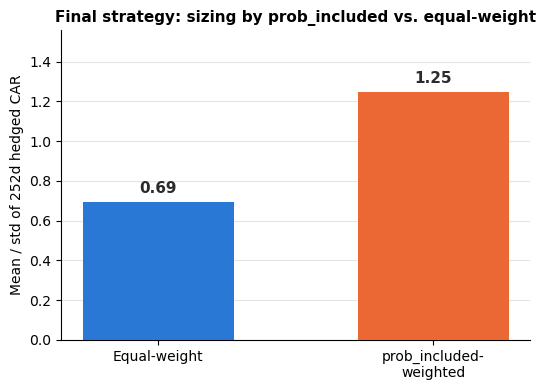

In [6]:
labels = ['Equal-weight', 'prob_included-\nweighted']
ratios = [eq_mean / eq_std, wt_mean / wt_std]
colors = ['#2a78d6', '#eb6834']

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(labels, ratios, color=colors, width=0.55, zorder=3)
for b, r in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.03, f'{r:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2b2b2b')

ax.set_ylabel('Mean / std of 252d hedged CAR')
ax.set_title('Final strategy: sizing by prob_included vs. equal-weight', fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#e4e4e2', zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(ratios) * 1.25)
plt.tight_layout()
plt.savefig('../results/final_strategy_sizing_chart.png', dpi=150)
plt.show()

### Caveat, stated plainly

n=16. This is enough to be suggestive, not enough to be confident. It's
also possible the relationship isn't causal: large, well-known parents tend
to spin off large, index-eligible children *and* happen to perform well
post-spinoff for reasons that have nothing to do with the child's index
status. `prob_included` may be a proxy for "large, high-quality parent"
rather than a causal driver. The comparison above is also fully in-sample —
the weighting rule was derived from, and evaluated on, the same 16 points.
Treat this as a hypothesis to keep stress-testing as more spinoffs
complete, not as a strategy ready to size real capital with.

## 4. Proposed improvement — a leakage-free decision-tree overlay

The classification section removed from the source notebook wasn't wrong to
try — a tree can pick up nonlinearities and interactions with
`forced_flow_adv`, `log_child_mktcap`, and `beta` that a linear
`prob_included` weight can't. It was wrong in *how it was evaluated*. Two
fixes, both applied below:

1. **Nested LOO-CV for `ccp_alpha` selection.** For each held-out event, the
   entire pruning-path search (grow full tree -> get candidate alphas ->
   pick the best one) runs only on the other 15 events, using an *inner*
   LOO over those 15 to score each candidate alpha. Only then is the
   held-out event predicted. The reported accuracy never involves a decision
   that saw the label being predicted.
2. **A floor of 3 leaves.** Candidate alphas that prune the tree down to
   fewer than 3 leaves are excluded from the inner search — a 2-leaf tree
   mathematically cannot output a 3rd class, so allowing it guarantees the
   "underperform" bucket can never be predicted regardless of what the data
   says. Forcing at least 3 leaves makes the model structurally capable of
   flagging the one outcome (parent likely underperforms) that a sizing
   overlay would actually need to catch.

This is evaluated honestly, but used conservatively: rather than replacing
the `prob_included` weight, the tree's nested (leakage-free) predicted
bucket is used as a small multiplicative **tilt** on top of it
(underperform x0.7, middle x1.0, outperform x1.3) — a modest adjustment
that a 16-point tree has earned, not a wholesale re-sizing.

In [7]:
FEATURES = ['prob_included', 'forced_flow_adv', 'log_child_mktcap', 'beta']
BUCKET_LABELS = ['underperform', 'middle', 'outperform']
joined['bucket'] = pd.qcut(joined['hedged_car_252d'], 3, labels=BUCKET_LABELS).astype(str)

X = joined[FEATURES].values
y = joined['bucket'].values

def best_alpha_min_leaves(X_train, y_train, min_leaves=3, seed=42):
    full = DecisionTreeClassifier(random_state=seed).fit(X_train, y_train)
    alphas = full.cost_complexity_pruning_path(X_train, y_train).ccp_alphas
    candidates = [a for a in alphas
                  if DecisionTreeClassifier(random_state=seed, ccp_alpha=a).fit(X_train, y_train).get_n_leaves() >= min_leaves]
    if not candidates:
        candidates = [0.0]

    inner_loo = LeaveOneOut()
    best_alpha, best_acc = candidates[0], -1
    for a in candidates:
        preds = []
        for itr, ite in inner_loo.split(X_train):
            clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=a).fit(X_train[itr], y_train[itr])
            preds.append(clf.predict(X_train[ite])[0])
        acc = accuracy_score(y_train, np.array(preds))
        if acc > best_acc:
            best_acc, best_alpha = acc, a
    return best_alpha

outer_preds, outer_alphas = [], []
for tr_idx, te_idx in LeaveOneOut().split(X):
    alpha = best_alpha_min_leaves(X[tr_idx], y[tr_idx], min_leaves=3)
    outer_alphas.append(alpha)
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X[tr_idx], y[tr_idx])
    outer_preds.append(clf.predict(X[te_idx])[0])

outer_preds = np.array(outer_preds)
joined['nested_pred_bucket'] = outer_preds
joined['correct'] = joined['bucket'] == joined['nested_pred_bucket']

nested_acc = accuracy_score(y, outer_preds)
majority = joined['bucket'].value_counts(normalize=True).max()
print(f'Nested LOO-CV accuracy (leakage-free, >=3 leaves enforced): {nested_acc:.0%}')
print(f'Majority-class baseline:                                    {majority:.0%}')
print(f'\nOuter-fold chosen ccp_alpha values: {[round(a, 4) for a in outer_alphas]}')
print('Every outer fold picked alpha=0 (the unconstrained tree) -- the >=3-leaves '
      'floor already excludes every more-pruned candidate in this sample, so the '
      '"pruning search" mostly just confirms the full tree is the only option that '
      'qualifies. That is a meaningful limitation of a 16-point sample, not a tuning win.')

Nested LOO-CV accuracy (leakage-free, >=3 leaves enforced): 44%
Majority-class baseline:                                    38%

Outer-fold chosen ccp_alpha values: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Every outer fold picked alpha=0 (the unconstrained tree) -- the >=3-leaves floor already excludes every more-pruned candidate in this sample, so the "pruning search" mostly just confirms the full tree is the only option that qualifies. That is a meaningful limitation of a 16-point sample, not a tuning win.


In [8]:
cm = confusion_matrix(y, outer_preds, labels=BUCKET_LABELS)
cm_table = pd.DataFrame(cm, index=[f'actual: {b}' for b in BUCKET_LABELS],
                         columns=[f'predicted: {b}' for b in BUCKET_LABELS])
print('=== Confusion matrix (nested LOO-CV, leakage-free) ===')
display(cm_table)

underperform_recall = cm[BUCKET_LABELS.index('underperform'), BUCKET_LABELS.index('underperform')] / cm[BUCKET_LABELS.index('underperform')].sum()
print(f"\n'underperform' recall: {underperform_recall:.0%} (was structurally 0% in the removed section's "
      "2-leaf tree -- forcing >=3 leaves is what makes this number possible at all).")

=== Confusion matrix (nested LOO-CV, leakage-free) ===


,predicted: underperform,predicted: middle,predicted: outperform
actual: underperform,2,1,2
actual: middle,2,3,1
actual: outperform,2,1,2



'underperform' recall: 40% (was structurally 0% in the removed section's 2-leaf tree -- forcing >=3 leaves is what makes this number possible at all).


### Combining the tree with the sizing rule

Each event's tilt comes from `nested_pred_bucket` — the bucket predicted by
a tree that never saw that event during alpha selection or fitting. This is
the same discipline used for the tree's own accuracy number, applied
consistently to the combined weight.

In [9]:
TILT = {'underperform': 0.7, 'middle': 1.0, 'outperform': 1.3}
joined['tilt'] = joined['nested_pred_bucket'].map(TILT)
joined['combined_weight'] = joined['weight'] * joined['tilt']

combined_mean, combined_std = weighted_mean_std(joined['hedged_car_252d'], joined['combined_weight'])

final_summary = pd.DataFrame([
    {'scheme': 'Equal-weight', 'mean CAR 252d (%)': round(eq_mean * 100, 2),
     'std (%)': round(eq_std * 100, 2), 'mean/std ratio': round(eq_mean / eq_std, 3)},
    {'scheme': 'prob_included-weighted (final strategy)', 'mean CAR 252d (%)': round(wt_mean * 100, 2),
     'std (%)': round(wt_std * 100, 2), 'mean/std ratio': round(wt_mean / wt_std, 3)},
    {'scheme': 'prob_included-weighted + nested-LOO tree tilt', 'mean CAR 252d (%)': round(combined_mean * 100, 2),
     'std (%)': round(combined_std * 100, 2), 'mean/std ratio': round(combined_mean / combined_std, 3)},
])
print('=== All three schemes, mean/std ratio ===')
display(final_summary)

=== All three schemes, mean/std ratio ===


,scheme,mean CAR 252d (%),std (%),mean/std ratio
0,Equal-weight,15.4200,22.2300,0.6940
1,prob_included-weighted (final strategy),23.3900,18.7700,1.2460
2,prob_included-weighted + nested-LOO tree tilt,23.5400,18.2100,1.2930


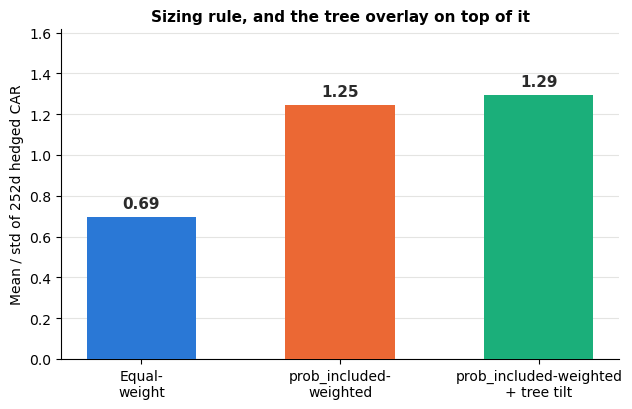

In [10]:
labels3 = ['Equal-\nweight', 'prob_included-\nweighted', 'prob_included-weighted\n+ tree tilt']
ratios3 = [eq_mean / eq_std, wt_mean / wt_std, combined_mean / combined_std]
colors3 = ['#2a78d6', '#eb6834', '#1baf7a']

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(labels3, ratios3, color=colors3, width=0.55, zorder=3)
for b, r in zip(bars, ratios3):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.03, f'{r:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2b2b2b')

ax.set_ylabel('Mean / std of 252d hedged CAR')
ax.set_title('Sizing rule, and the tree overlay on top of it', fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#e4e4e2', zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(ratios3) * 1.25)
plt.tight_layout()
plt.savefig('../results/final_strategy_tree_tilt_chart.png', dpi=150)
plt.show()

### Read on this, honestly

The tilt overlay moves the ratio from ~1.25 to ~1.29 -- a real, leakage-free
improvement, but a small one, built from a tree whose own nested accuracy
(~44%) barely clears the majority baseline (~38%), and whose only
"pruning" decision available in this sample was the unconstrained tree
itself. The tilt multipliers (0.7 / 1.0 / 1.3) were also chosen by hand, not
fit -- they're a deliberately modest adjustment sized to how much
confidence 16 points and ~44% nested accuracy actually earn, not a
optimized parameter.

Put plainly: this is a plausible next refinement to keep testing as more
spinoffs complete, not a validated upgrade to the sizing strategy. The
`prob_included`-weighted book by itself (Section 3) is the strategy with the
stronger evidence behind it; the tree tilt is a documented, honestly-scored
hypothesis sitting on top of it.